In [56]:
import sys
print(sys.version)

3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]


In [57]:
import math
print("math imported")

math imported


In [58]:
import numpy as np
print("numpy imported")

numpy imported


In [59]:
import pandas as pd
print("pandas imported")

pandas imported


In [60]:
import scanpy

In [61]:
print(scanpy.__version__)

1.12.1


/var/folders/ys/f4dnpd295d91m1ctpdbcgl3w0000gn/T/ipykernel_94926/2935678766.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(scanpy.__version__)


In [62]:
import scanpy as sc

print("starting")

adata = sc.datasets.pbmc3k()

print("finished")

starting
finished


In [63]:
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [64]:
adata.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [65]:
adata.var.head()

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


In [66]:
adata.X.shape

(2700, 32738)

In [67]:
print(adata)
adata.obs.head()
adata.var.head()
adata.X.shape

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


(2700, 32738)

In [68]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")

In [69]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")

In [70]:
adata.var.head()

,gene_ids,mt
index,,
MIR1302-10,ENSG00000243485,False
FAM138A,ENSG00000237613,False
OR4F5,ENSG00000186092,False
RP11-34P13.7,ENSG00000238009,False
RP11-34P13.8,ENSG00000239945,False


In [71]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

In [72]:
adata.obs.columns

Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt'],
      dtype='object')

In [73]:
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242


In [74]:
#visualizing QC metrics before filtering
#looking for low quality cells and outliers

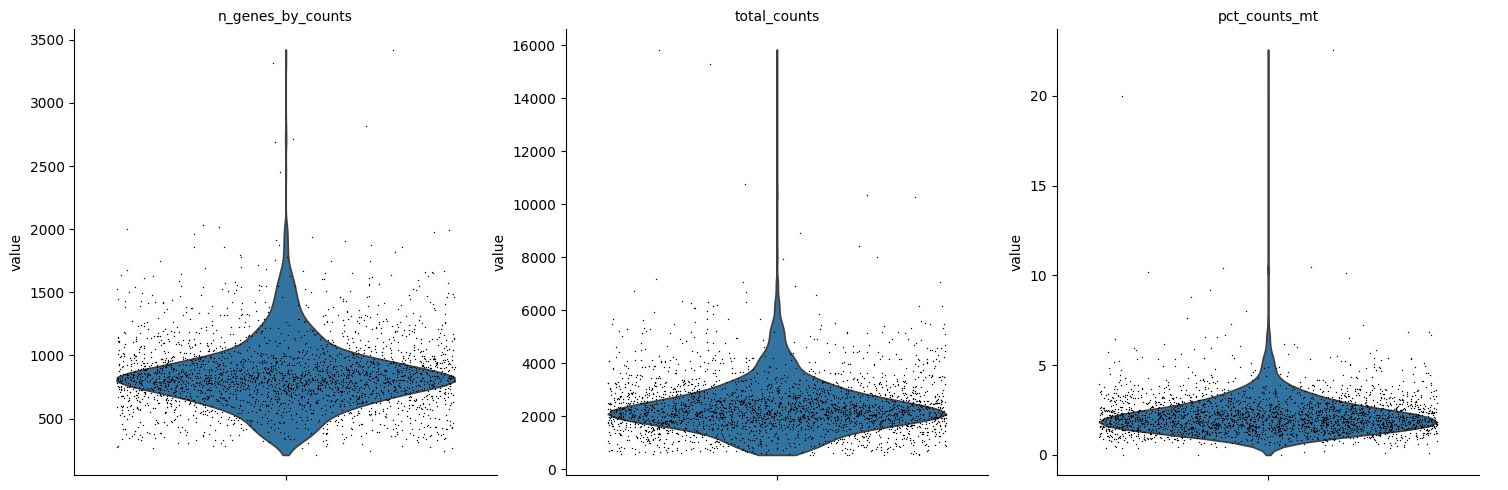

In [75]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
) 

In [76]:
import matplotlib.pyplot as plt
print ("imported matplotlib")

imported matplotlib


In [77]:
#visualizing relationship between QC metrics 

<Axes: xlabel='total_counts', ylabel='n_genes_by_counts'>

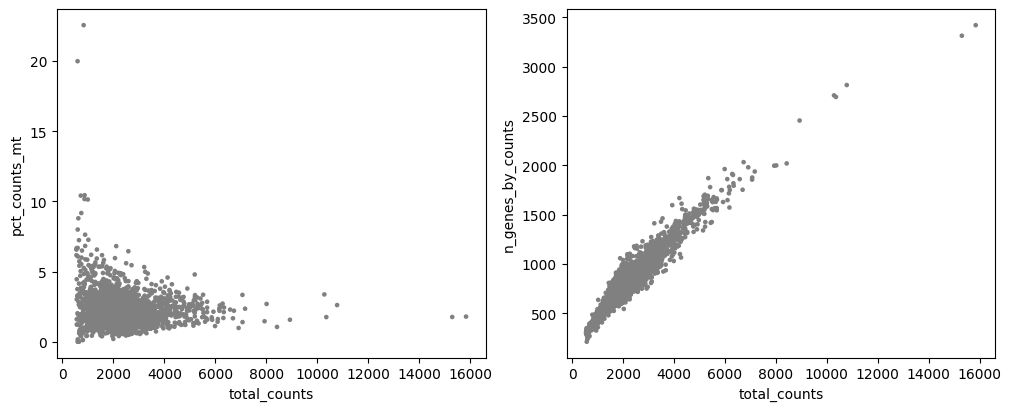

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

sc.pl.scatter(
 adata,
 x="total_counts",
 y="pct_counts_mt",
 show=False,
 ax=axs[0]
)

sc.pl.scatter(
 adata,
 x="total_counts",
 y="n_genes_by_counts",
 show=False,
 ax=axs[1]
)

In [79]:
#The relationship between total counts and detected genes is linear, suggesting that cells with higher RNA content generally exhibit more detected genes. A small subset of cells shows elevated mitochondrial percentages (>10%), indicating stressed or low quality cells.

In [80]:
adata = adata[
    (adata.obs.n_genes_by_counts > 200)
    & (adata.obs.n_genes_by_counts < 2500)
    & (adata.obs.pct_counts_mt < 5),
    :
].copy()

In [81]:
adata.shape

(2638, 32738)

In [82]:
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242


In [83]:
adata.obs.columns

Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt'],
      dtype='object')

In [84]:
test = adata.obs["n_genes_by_counts"] > 200
print(test.sum())

2638


In [85]:
adata_filtered = adata[
    (adata.obs.n_genes_by_counts > 200)
]

In [86]:
print(adata_filtered.shape)

(2638, 32738)


In [87]:
print(adata.shape)

(2638, 32738)


In [88]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [89]:
sc.pp.log1p(adata)

In [90]:
adata

AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'

In [91]:
sc.pp.highly_variable_genes()

TypeError: highly_variable_genes() missing 1 required positional argument: 'adata'

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [ ]:
print(adata.var['highly_variable'].value_counts())

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
sc.tl.pca(adata)

In [ ]:
adata.obsm["X_pca"]

In [ ]:
from sklearn.model_selection import train_test_split
print ("imported train_test_split")

In [93]:
import os

print(os.getcwd())

/Users/palaksharma/aging-clock-env


In [94]:
import os

print(os.path.exists("../data"))
print(os.path.exists("../data/processed"))

False
False


In [95]:
import os

os.makedirs("../data/processed", exist_ok=True)

adata.write("../data/processed/aging_data_qc.h5ad")

In [96]:
adata.write("aging_data_qc.h5ad")

In [97]:
print(adata)

AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'


In [98]:
adata.write("aging_data_qc.h5ad")

In [99]:
import os
print(os.getcwd())

/Users/palaksharma/aging-clock-env


In [100]:
import os

print(os.listdir())

['aging_data_qc.h5ad', 'bin', 'include', 'etc', 'pyvenv.cfg', '.gitignore', 'lib', '.ipynb_checkpoints', '01_data_loading_and_QC.ipynb', 'data', 'share']


In [101]:
adata.write("aging_data_qc.h5ad")

In [102]:
import os

print(os.path.exists("aging_data_qc.h5ad"))

True


In [103]:
print("Saved successfully")

Saved successfully


In [104]:
os.listdir()

['aging_data_qc.h5ad',
 'bin',
 'include',
 'etc',
 'pyvenv.cfg',
 '.gitignore',
 'lib',
 '.ipynb_checkpoints',
 '01_data_loading_and_QC.ipynb',
 'data',
 'share']

In [105]:
import os

print(os.listdir("data"))

['pbmc3k_raw.h5ad']


In [106]:
import os

os.makedirs("data/processed", exist_ok=True)

In [107]:
import shutil

shutil.move(
    "aging_data_qc.h5ad",
    "data/processed/aging_data_qc.h5ad"
)

'data/processed/aging_data_qc.h5ad'

In [108]:
adata.write("data/processed/aging_data_qc.h5ad")